In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Startup_Scoring_Dataset.csv")
print(df.head())

  startup_id  team_experience  market_size_million_usd  monthly_active_users   
0       S001                7                      789                 66299  \
1       S002                4                      939                 34866   
2       S003                8                       42                 73630   
3       S004                5                       57                 93657   
4       S005                7                      512                 61187   

   monthly_burn_rate_inr  funds_raised_inr  valuation_inr  
0                6091495           4183839      263247468  
1                9106842            666326      172927107  
2                8817088            649150      313090455  
3                6374167          20153173      305887183  
4                 841971            118834       84815222  


In [3]:
# Min-Max Normalization (higher = better)
for col in ['team_experience', 'market_size_million_usd', 'monthly_active_users', 'funds_raised_inr', 'valuation_inr']:
    df[f'{col}_normalized'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# Invert burn rate (lower = better)
df['monthly_burn_rate_normalized'] = 1 - ((df['monthly_burn_rate_inr'] - df['monthly_burn_rate_inr'].min()) / 
                                      (df['monthly_burn_rate_inr'].max() - df['monthly_burn_rate_inr'].min()))

Metric	Weight	Reason
Team Experience	20%	Critical for execution.
Market Size (TAM)	20%	Larger markets = higher upside.
Monthly Active Users	25%	Traction indicator.
Burn Rate	15%	Efficiency metric (lower = better).
Funds Raised	10%	Investor confidence proxy.
Valuation	10%	Market validation.

In [4]:
df['score'] = (
    0.20 * df['team_experience_normalized'] +
    0.20 * df['market_size_million_usd_normalized'] +
    0.25 * df['monthly_active_users_normalized'] +
    0.15 * df['monthly_burn_rate_normalized'] +  # Already inverted
    0.10 * df['funds_raised_inr_normalized'] +
    0.10 * df['valuation_inr_normalized']
) * 100  # Scale to 0-100

In [5]:
#top 10
top_10 = df.sort_values('score', ascending=False).head(10)[['startup_id', 'score']]
print("Top 10 Startups:")
print(top_10)

#bottom 10

bottom_10 = df.sort_values('score').head(10)[['startup_id', 'score']]
print("Bottom 10 Startups:")
print(bottom_10)

Top 10 Startups:
   startup_id      score
5        S006  82.864721
76       S077  77.336449
12       S013  75.527789
44       S045  74.425136
96       S097  73.193190
81       S082  72.711318
32       S033  72.298691
42       S043  71.736046
28       S029  71.569768
65       S066  70.161179
Bottom 10 Startups:
   startup_id      score
54       S055  24.203357
51       S052  28.997828
78       S079  29.052172
83       S084  29.456801
57       S058  30.284652
25       S026  31.277294
22       S023  31.612326
97       S098  32.206421
60       S061  32.382559
73       S074  33.901810


Visualisation

C:\Users\ashut\AppData\Local\Temp\ipykernel_4872\1432165761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='startup_id', data=top_10, palette='viridis')


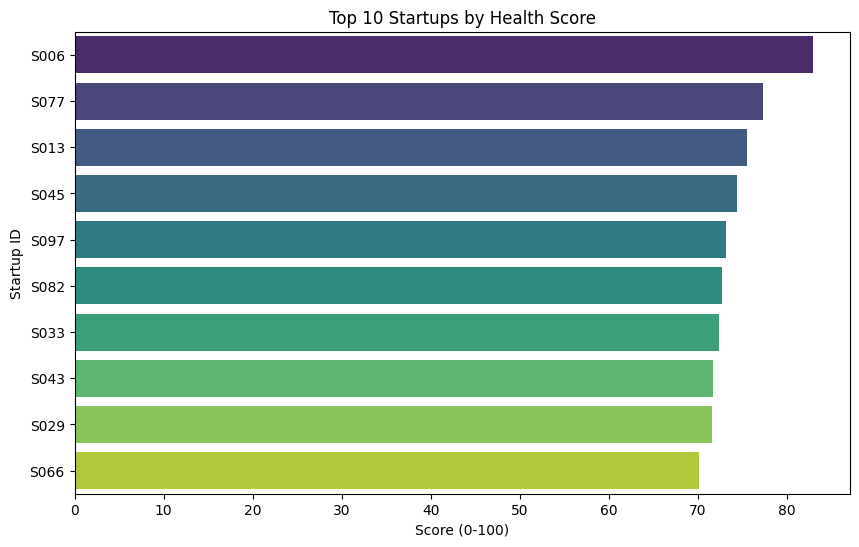

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x='score', y='startup_id', data=top_10, palette='viridis')
plt.title("Top 10 Startups by Health Score")
plt.xlabel("Score (0-100)")
plt.ylabel("Startup ID")
plt.show()

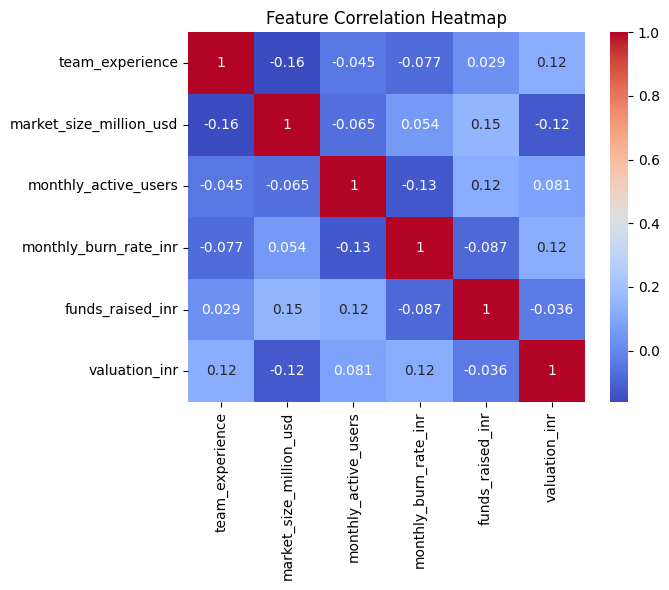

In [7]:
corr = df[['team_experience', 'market_size_million_usd', 'monthly_active_users', 
           'monthly_burn_rate_inr', 'funds_raised_inr', 'valuation_inr']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

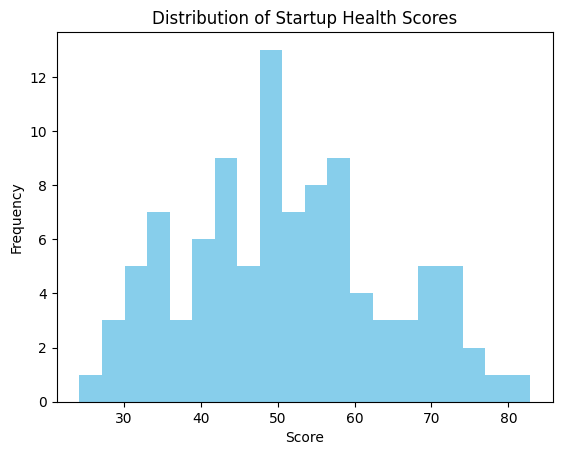

In [8]:
plt.hist(df['score'], bins=20, color='skyblue')
plt.title("Distribution of Startup Health Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

making model to predict high-potential startups


In [9]:
# Define top 20% as high-potential
df['high_potential'] = np.where(df['score'] >= np.percentile(df['score'], 80), 1, 0)

In [10]:
features = ['team_experience', 'market_size_million_usd', 'monthly_active_users', 
            'monthly_burn_rate_inr', 'funds_raised_inr', 'valuation_inr']
X = df[features]
y = df['high_potential']

model training

In [11]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [12]:
#Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.75      0.86         4

    accuracy                           0.95        20
   macro avg       0.97      0.88      0.91        20
weighted avg       0.95      0.95      0.95        20

Accuracy: 0.95


<Figure size 1000x600 with 0 Axes>

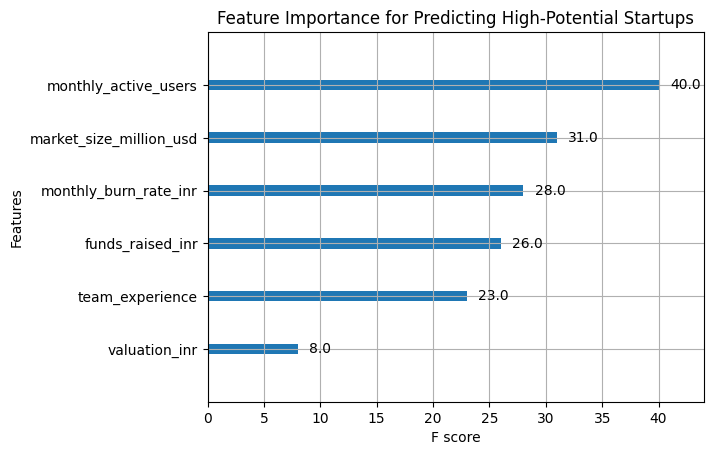

In [13]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(model)
plt.title("Feature Importance for Predicting High-Potential Startups")
plt.show()

mothly active users have high impact

In [14]:
# Sample new startup data
new_startup = pd.DataFrame({
    'team_experience': [8],
    'market_size_million_usd': [500],
    'monthly_active_users': [75000],
    'monthly_burn_rate_inr': [2000000],  
    'funds_raised_inr': [30000000],
    'valuation_inr': [400000000]
})

# prediction
prediction = model.predict(new_startup)
print("High-potential?" , "Yes" if prediction[0] == 1 else "No")

High-potential? Yes


In [15]:
import joblib
joblib.dump(model, 'startup_potential_predictor.pkl')

['startup_potential_predictor.pkl']

"Startup Failure Risk" Dashboard

In [ ]:
%pip install shap
import shap


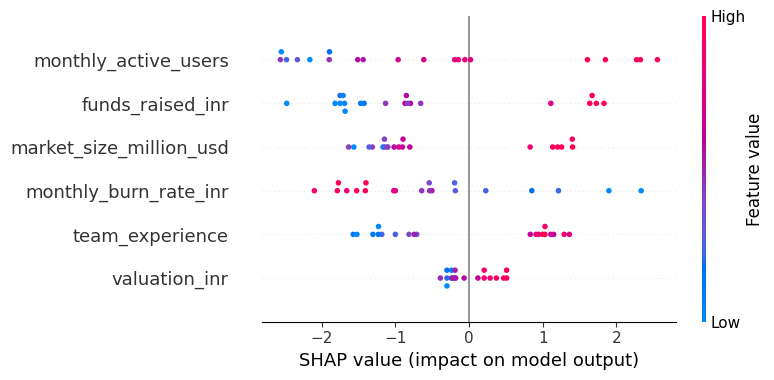

In [18]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
%pip install dash

In [22]:
import dash
from dash import dcc, html
import plotly.express as px

app = dash.Dash()
app.layout = html.Div([
    dcc.Graph(figure=px.scatter(df, x='monthly_active_users', y='score', color='high_potential'))
])
app.run()